## Processing PACE and EMIT Data

Authors: Skye Caplan (NASA, SSAI), Erik Bolch (USGS)

Last updated: 05/15/2026

[edl]: https://urs.earthdata.nasa.gov/
[oci-data-access]: https://oceancolor.gsfc.nasa.gov/resources/docs/tutorials/notebooks/oci_data_access/
[emit-data-access]: https://nasa.github.io/VITALS/python/Exploring_EMIT_L2A_RFL.html
[help-hub]: https://nasa.github.io/oceandata-notebooks/
[vitals]: https://nasa.github.io/VITALS/

<div class="alert alert-info" role="alert">

An [Earthdata Login][edl] account is required to access data from the NASA Earthdata system, including NASA PACE and EMIT data.

</div>

## Summary
NASA's Plankton, Aerosol, Cloud, ocean Ecosystem (PACE) satellite mission and Earth Surface Mineral Dust Source Investigation (EMIT) sensor aboard the International Space Station (ISS) both make hyperspectral observations of the Earth's surface. Taking into account their different spectral, spatial, and temporal coverage, these instruments' complementary capabilities provide a wealth of new opportunities when used in concert. In this series of tutorials, we will demonstrate how to find, prepare, and use data from PACE and EMIT together, illustarting both missions' strengths and how they can help fill in each others' gaps. 

This is the second tutorial in the PACE-EMIT series. This notebook will demonstrate how to preprocess the reflectance data downloaded from the first tutorial, `01_Colocate_PACE_EMIT_data`, so that they can be used together to investigate science questions. We will use functions from the `emit_tools` and `pace_tools` modules to orthorectify, geolocate, and merge EMIT and PACE Ocean Color Instrument (OCI) data where necessary. Those modules will then also be used to place OCI and EMIT granules on an equivalent, stackable grid. We can then compare the data from the two sensors. These techniques will also be integral to our case study analysis in the third tutorial, `03_Wildfires_with_PACE_EMIT`.

## Background

The goal of this tutorial series is to look at how EMIT and PACE OCI make complementary observations of the same location. Before getting to the science in notebook 3, the datasets require some preprocessing to help make working with them more intuitive. This is especially true considering we have data from two different instruments with unique orbit and observation characteristics. 

Recall that the reflectances downloaded in the first notebook are in raw Level-2 (L2) data format, meaning both datasets are still in swath resolution. Additionally, neither dataset is geolocated or masked for quality issues. Referring to the instrument summary table below, we also know that EMIT and PACE OCI are not at the same spatial resolution, which can make comparing spectra more complicated. Using pre-written tools for each instrument, we can geolocate and grid the data so that each pixel is associated with a physical latitude/longitude coordinate. To deal with the different pixel sizes, we can either upscale PACE OCI to the finer EMIT grid, or downscale EMIT to the coarser PACE OCI grid, ensuring the data are stackable and directly comparable.

| Resolutions | EMIT    | PACE OCI |
| ----------- | ------- | -------- |
| Spatial     | 60 m    | 1.2 km (at nadir)|
| Temporal    | Variable| 1 - 2 days|
| Spectral Range | 380 - 2500 nm | 350 - 895, with 7 multispectral SWIR bands from 935-2258 nm|
| Spectral Sampling | 7.5 nm | 2.5 nm, with 1.25 nm in some spectral regions |

## Learning Objectives

At the end of this notebook, you will know how to:
- Use prebuilt tools to orthorectify, merge, and geolocate EMIT and PACE OCI data
- Upscale PACE OCI to EMIT resolution
- Compare spectral signatures over a region of interest (ROI)

## Contents
1. [Setup](#1.-Setup)
2. [Preprocessing Instrument Data](#2.-Preprocessing-Instrument-Data)
3. [Grid Alignment](#3.-Grid-Alignment)
4. [Spectral Comparisons](#4.-Spectral-Comparisons)

## 1. Setup

Begin by importing all of the packages used in this notebook.

In [ ]:
import os
import glob
import cartopy
import skimage
import numpy as np 
import xarray as xr 
import hvplot.xarray
import holoviews as hv
import rioxarray as rio
import geopandas as gpd
import cartopy.crs as ccrs 
import matplotlib.pyplot as plt 
from pathlib import Path

os.chdir(os.path.abspath(os.path.join(get_ipython().starting_dir, os.pardir)))
from modules import pace_tools as pace
from modules import emit_tools as emit

import warnings
warnings.filterwarnings('ignore')

def plot_features(ax, gridline_alpha=1):
    """
    Function to add gridlines and cartopy features to a figure.
    Args:
        ax - matplotlib Axes object on which to plot the features
        gridline_alpha - fractional opacity of gridlines on the plot. Will also 
             make sure x, y axes are labelled with lon/lats, respectively. 0 will 
             include axes labels but not plot gridlines
    """
    for a in range(len(ax)):
        ax[a].gridlines(draw_labels={"left": "y", "bottom": "x"}, linewidth=0.25, alpha=gridline_alpha)
        ax[a].coastlines(linewidth=0.5)
        ax[a].add_feature(cartopy.feature.OCEAN, edgecolor="w", linewidth=0.01)
        ax[a].add_feature(cartopy.feature.LAND, edgecolor="w", linewidth=0.01)
        ax[a].add_feature(cartopy.feature.LAKES, edgecolor="w", linewidth=0.01)

# Set up extents with GDF
gdf_bbox = gpd.read_file("emit_pace/data/grampians_bbox.geojson")

In the last notebook, we found and downloaded EMIT and PACE data corresponding to pre-fire and post-fire days for the Grampians National Park fire in Victoria, Australia, as well as several PACE OCI granules between these days. We'll be using those files in this notebook, and so define their paths in the cell below. Please change these paths to your own download locations if they differ from those below.

In [2]:
emit_paths = sorted(glob.glob("emit_pace/data/EMIT_L2A*.nc"))
oci_paths = sorted(glob.glob("emit_pace/data/PACE_OCI*.nc"))
oci_ts_paths = sorted(glob.glob("emit_pace/ts_data/PACE_OCI*.nc"))

# Make into Path objects
emit_paths = [Path(i) for i in emit_paths]
oci_paths = [Path(i) for i in oci_paths]
oci_ts_paths = [Path(i) for i in oci_ts_paths]

If for some reason you need to download these files, uncomment and run the cell below.

In [3]:
# Download Data

# import earthaccess
#emit_urls = ["https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL2ARFL.001/EMIT_L2A_RFL_001_20241114T035759_2431902_009/EMIT_L2A_RFL_001_20241114T035759_2431902_009.nc",
#             "https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL2ARFL.001/EMIT_L2A_RFL_001_20241114T035759_2431902_009/EMIT_L2A_MASK_001_20241114T035759_2431902_009.nc",
#             "https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL2ARFL.001/EMIT_L2A_RFL_001_20241114T035747_2431902_008/EMIT_L2A_RFL_001_20241114T035747_2431902_008.nc",
#             "https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL2ARFL.001/EMIT_L2A_RFL_001_20241114T035747_2431902_008/EMIT_L2A_MASK_001_20241114T035747_2431902_008.nc",
#             "https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL2ARFL.001/EMIT_L2A_RFL_001_20250319T022818_2507801_008/EMIT_L2A_RFL_001_20250319T022818_2507801_008.nc",
#             "https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL2ARFL.001/EMIT_L2A_RFL_001_20250319T022818_2507801_008/EMIT_L2A_MASK_001_20250319T022818_2507801_008.nc",
#             "https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL2ARFL.001/EMIT_L2A_RFL_001_20250319T022830_2507801_009/EMIT_L2A_RFL_001_20250319T022830_2507801_009.nc",
#             "https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL2ARFL.001/EMIT_L2A_RFL_001_20250319T022830_2507801_009/EMIT_L2A_MASK_001_20250319T022830_2507801_009.nc"
#             ]
# NOTE: We can use a handful of these or only host the subsets to reduce data size if necessary (sc)
#pace_urls = ['https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20241114T035224.L2.SFREFL.V3_1.nc',
#             'https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20241215T033822.L2.SFREFL.V3_1.nc',
#             'https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20250101T033916.L2.SFREFL.V3_1.nc',
#             'https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20250118T033938.L2.SFREFL.V3_1.nc',
#             'https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20250122T041511.L2.SFREFL.V3_1.nc',
#             'https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20250205T040925.L2.SFREFL.V3_1.nc',
#             'https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20250211T042542.L2.SFREFL.V3_1.nc',
#             'https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20250212T032254.L2.SFREFL.V3_1.nc',
#             'https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20250224T035613.L2.SFREFL.V3_1.nc',
#             'https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20250301T033714.L2.SFREFL.V3_1.nc',
#             'https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20250304T034526.L2.SFREFL.V3_1.nc',
#             'https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20250305T042058.L2.SFREFL.V3_1.nc',
#             'https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20250307T035339.L2.SFREFL.V3_1.nc',
#             'https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20250313T041003.L2.SFREFL.V3_1.nc',
#             'https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20250319T035224.L2.SFREFL.V3_1.nc',
#            ]

#earthaccess.login()
#emit_paths = earthaccess.download(emit_urls, "emit_pace/data/downloaded")
#oci_paths = earthaccess.download(pace_urls, "emit_pace/data/downloaded")

## 2. Preprocessing Instrument Data

Before we can use these data for science, there are a couple steps we should take to preprocess the files so that they are easier to handle in the long run. Recall from the previous tutorial that we are using Level-2 (L2) data. Raw L2 data are still in the instrument swath, or in other words, not geolocated or on any type of uniform grid. As such, our pixels are yet associated with any coordinates, and can represent different sizes on the ground. This is especially true in the case of PACE OCI, since its swath is very wide, but applies to EMIT as well. The first notebook also showed that our region of interest (ROI) spans two EMIT granules, but is only a small part of any PACE OCI scenes. To simplify our workflow and minimize the size of our datasets, we can use tools written specifically for managing these instruments' data. We'll preprocess the data from each mission separately to work with their distinct characteristics, demonstrating a few different ways of handling data.

### EMIT Data

For EMIT data, we want to orthorectify, geolocate, and merge the pre-fire granules and post-fire granules, respectively, so that we have one file for each date covering the full ROI. The cell below contains a function which combines all of these steps into one by calling functions from the `emit_tools` module. More information on the tools below can be found in the [EMIT-Data-Resources repository](https://github.com/nasa/EMIT-Data-Resources).

Briefly, the `process_and_merge_emit` function calls on `emit_xarray` to open both the reflectance and mask files, and uses the mask to remove any unwanted pixels (clouds, bad data bands, etc.). Then, the `spatial_subset` function is called to clip the data only to the ROI, in this case a bounding box around Grampians National Park. Finally, both granules are merged so the ROI is contained in one file, and that file is saved in an output directory of the user's choice. 

In [3]:
def process_and_merge_emit(rfl_paths, mask_paths, polygon_path, mask_bands, outdir):
    """Preprocess a list of EMIT RFL+MASK pairs and write a single merged NetCDF.
    Args:
        rfl_paths - list of Paths to EMIT reflectance files to process
        mask_paths - list of Paths to EMIT mask files corresponding the reflectance
                     paths to use in processing
        polygon_path - Path to polygon to use for subsettnig
        mask_bands - list of which EMIT mask bands to use
        outdir - Path to save merged output to
    Returns:
        out_path - Path to merged output
    """
    out_path = outdir / f"{rfl_paths[0].stem}_ortho_merged.nc"
    if out_path.exists():
        print("Output already exists!")
        return out_path
    gdf = gpd.read_file(polygon_path)

    scenes = []
    for rfl_path, mask_path in zip(rfl_paths, mask_paths):
        rfl  = emit.emit_xarray(rfl_path)
        mask = (emit.emit_xarray(mask_path)["mask"]
                    .sel(mask_bands=mask_bands).any("mask_bands").astype(int))
        rfl  = rfl.where(mask == 0)
        rfl  = emit.spatial_subset(rfl, gdf)
        scenes.append(emit.ortho_xr(rfl))

    merged = emit.merge_emit(scenes, gdf)
    
    merged.to_netcdf(out_path)
    return out_path

We set up the arguments for the `process_and_merge_emit` function in the cell below. Let's also print out the list of sorted EMIT files so we know which indices to use for the function call.

In [4]:
OUTDIR = Path.cwd() / "emit_pace" / "data" / "outputs"
gdf_path = "emit_pace/data/grampians_bbox.geojson"
mask_bands = ['Cloud flag','Cirrus flag','Water flag','Spacecraft Flag']

emit_paths

[PosixPath('emit_pace/data/EMIT_L2A_MASK_001_20241114T035747_2431902_008.nc'),
 PosixPath('emit_pace/data/EMIT_L2A_MASK_001_20241114T035759_2431902_009.nc'),
 PosixPath('emit_pace/data/EMIT_L2A_MASK_001_20250319T022818_2507801_008.nc'),
 PosixPath('emit_pace/data/EMIT_L2A_MASK_001_20250319T022830_2507801_009.nc'),
 PosixPath('emit_pace/data/EMIT_L2A_RFL_001_20241114T035747_2431902_008.nc'),
 PosixPath('emit_pace/data/EMIT_L2A_RFL_001_20241114T035759_2431902_009.nc'),
 PosixPath('emit_pace/data/EMIT_L2A_RFL_001_20250319T022818_2507801_008.nc'),
 PosixPath('emit_pace/data/EMIT_L2A_RFL_001_20250319T022830_2507801_009.nc')]

We can then call the function with the correct filepaths. Note that this cell should take about a minute to run fully. The resulting files in the output filepath will contain the merged, masked, and subsetted to the ROI.

In [5]:
prefire_emit_path = process_and_merge_emit(rfl_paths=emit_paths[4:6],
                                            mask_paths=emit_paths[0:2],
                                            polygon_path=gdf_path,
                                            mask_bands=mask_bands,
                                            outdir=OUTDIR)
postfire_emit_path = process_and_merge_emit(rfl_paths=emit_paths[6:8],
                                             mask_paths=emit_paths[2:4],
                                             polygon_path=gdf_path,
                                             mask_bands=mask_bands,
                                             outdir=OUTDIR)

Output already exists!
Output already exists!


Once processing is complete, we can take a look at the contents of the merged files, and plot the data as well.

In [7]:
prefire_emit_ds = xr.open_dataset(prefire_emit_path)
postfire_emit_ds = xr.open_dataset(postfire_emit_path)

prefire_emit_ds

<xarray.Dataset> Size: 2GB
Dimensions:           (latitude: 1420, longitude: 931, wavelengths: 285)
Coordinates:
  * latitude          (latitude) float64 11kB -36.87 -36.87 ... -37.64 -37.64
  * longitude         (longitude) float64 7kB 142.2 142.2 142.2 ... 142.7 142.7
    elev              (latitude, longitude) float32 5MB ...
  * wavelengths       (wavelengths) float32 1kB 381.0 388.4 ... 2.493e+03
    good_wavelengths  (wavelengths) float32 1kB ...
    fwhm              (wavelengths) float32 1kB ...
Data variables:
    reflectance       (latitude, longitude, wavelengths) float32 2GB ...
    spatial_ref       int64 8B ...
Attributes: (12/41)
    ncei_template_version:             NCEI_NetCDF_Swath_Template_v2.0
    summary:                           The Earth Surface Mineral Dust Source ...
    keywords:                          Imaging Spectroscopy, minerals, EMIT, ...
    Conventions:                       CF-1.63
    sensor:                            EMIT (Earth Surface Mineral Dust Sourc...
    instrument:                        EMIT
    ...                                ...
    geotransform:                      [ 1.42180140e+02  5.42232520e-04  0.00...
    day_night_flag:                    Day
    title:                             EMIT L2A Estimated Surface Reflectance...
    granule_id:                        EMIT_L2A_RFL_001_20241114T035747_24319...
    subset_downtrack_range:            [ 388 1279]
    subset_crosstrack_range:           [   0 1232]

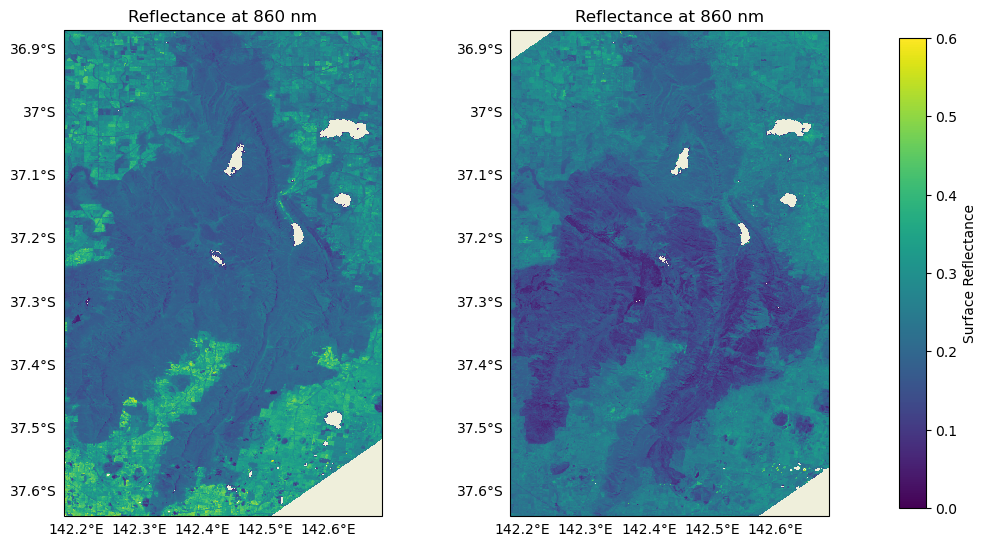

In [8]:
fig, ax = plt.subplots(1,2, figsize=(9,5),sharey=True, 
                       subplot_kw={"projection": ccrs.PlateCarree()})
fig.tight_layout(pad=0.5)
im = prefire_emit_ds["reflectance"].sel(wavelengths=860, 
                                 method="nearest").plot(ax=ax[0],vmin=0, vmax=0.6,
                                                        add_colorbar=False)
postfire_emit_ds["reflectance"].sel(wavelengths=860, 
                             method="nearest").plot(ax=ax[1],vmin=0, vmax=0.6, 
                                                    add_colorbar=False)

plot_features(ax.flatten(), gridline_alpha=0)
bbox = [141.9385, -37.74163, 142.77324, -36.79961]

cax = fig.add_axes([1.0025, 0.03, 0.03, 0.94]) 
fig.colorbar(im, cax=cax, label="Surface Reflectance")

ax[0].set_title("Reflectance at 860 nm")
ax[1].set_title("Reflectance at 860 nm")   

plt.show()

We have successfully clipped our EMIT data, and that the data represent physical locations with coordinates. Let's do the same for the PACE OCI reflectances.

### PACE OCI Data

For PACE data, we'll need to subset, mask, and geolocate each granule. A merge is not needed since the full ROI is contained in each scene. The `pace_tools` module provides a suite of functions for working with PACE OCI data, similar to the `emit_tools` module, which the `process_pace` function calls below to accomplish the preprocessing. 

Briefly, the function uses the `open_l2` and `mask_ds` functions to remove pixels containing clouds or water. Then, the `grid_data` function is called with a user-defined resolution to grid the data. We will use a resolution of 0.015 degrees (~1.67 km at the equator) to account for OCI's wide swath. Once the data is gridded, `xarray`'s `.sel()` method can be used to subset the data based on the coordinates of a bounding box. More information on these tools can be found on the [Help Hub](https://nasa.github.io/oceandata-notebooks/). 

Note that in the cell below, we'll process both the pre- and post-fire data days as well as the time series data. The cell should take under 5 minutes to complete. 

In [9]:
def process_pace(pace_path, resolution, bbox, outdir):
    out_path = outdir / f"{pace_path.stem}_ortho_subset.nc"
    if out_path.exists():
        print("Output already exists!")
        return out_path
    ds = pace.open_l2(pace_path)
    ds = pace.mask_ds(ds, flag=["CLDICE","LAND"], reverse=[False,True])
    ds = pace.grid_data(ds, resolution=resolution)
    ds_sub = ds.sel({"latitude":slice(bbox[3],bbox[1]), "longitude":slice(bbox[0],bbox[2])})
    ds_sub.to_netcdf(out_path)
    return out_path

resolution = (0.015,0.015)
pace_subsets = [process_pace(oci_path, resolution, gdf_bbox.total_bounds, OUTDIR) for oci_path in oci_paths]
pace_ts_subsets = [process_pace(oci_path, resolution, gdf_bbox.total_bounds, OUTDIR) for oci_path in oci_ts_paths]

Output already exists!
Output already exists!
Output already exists!
Output already exists!
Output already exists!
Output already exists!
Output already exists!
Output already exists!
Output already exists!
Output already exists!
Output already exists!
Output already exists!
Output already exists!
Output already exists!
Output already exists!


Let's plot the output pre- and post-fire OCI granules to see the processed data:

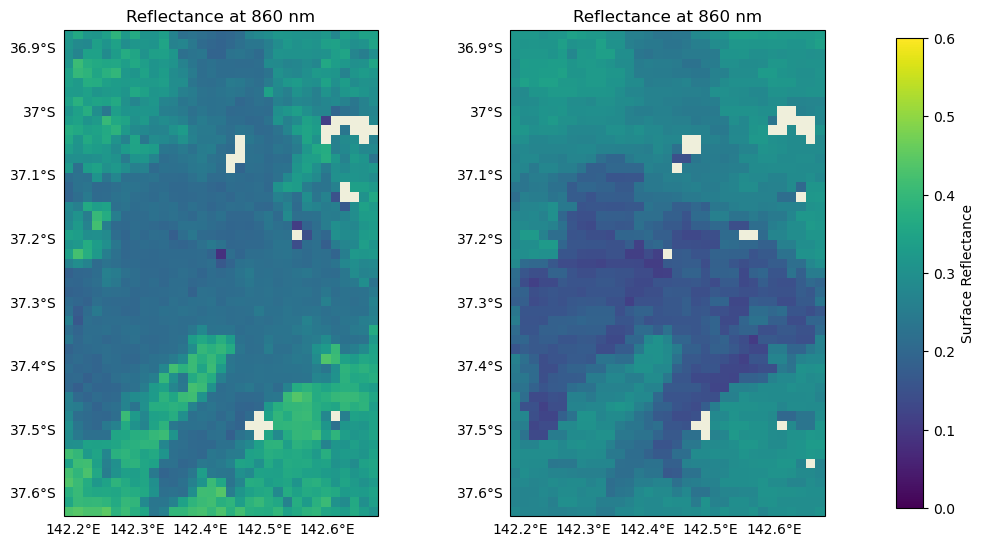

In [10]:
prefire_oci_ds = xr.open_dataset(pace_subsets[0])
postfire_oci_ds = xr.open_dataset(pace_subsets[1])

fig, ax = plt.subplots(1,2, figsize=(9,5),sharey=True, 
                       subplot_kw={"projection": ccrs.PlateCarree()})
fig.tight_layout(pad=0.5)
prefire_oci_ds["rhos"].sel(wavelength_3d=860, 
                    method="nearest").plot(ax=ax[0],vmin=0, vmax=0.6, add_colorbar=False)
im = postfire_oci_ds["rhos"].sel(wavelength_3d=860, 
                          method="nearest").plot(ax=ax[1],vmin=0, vmax=0.6, add_colorbar=False)

plot_features(ax.flatten(), gridline_alpha=0)

cax = fig.add_axes([1.0025, 0.03, 0.03, 0.94])
fig.colorbar(im, cax=cax, label='Surface Reflectance')

ax[0].set_title("Reflectance at 860 nm")
ax[1].set_title("Reflectance at 860 nm")

plt.show()

The preprocessing for PACE data has worked as well! A quick glance at the above OCI plots compared to those from EMIT illustrates the difference in spatial scale covered by the two missions, but the overall reflectances at 860 nm looks similar. 

We can compare full spectra from both instruments for a more detailed view of the data. This could be done by using both datasets at their nominal resolutions, but some analyses may benefit from or even require a PACE dataset with the same resolution as the EMIT dataset (or vise versa). For example, upscaling methods are often employed to prepare a consistent grid for analysis when the goal is preserve fine resolution details from the higher resolution dataset. Coarsening, on the other hand, can be useful to reduce noise in high resolution imagery, or to reduce file sizes for large scale regional and global studies. 

Upscaling the OCI data would be useful for the next tutorial in this series since we want to retain features from the EMIT scene while having both datasets on the same grid. We'll use the `grid_data` function from the `pace_tools` module to regrid our OCI data to a finer resolution. 

## 3. Grid Alignment

First, let's get an idea of what the original EMIT and PACE grids look like overlaid on one another.

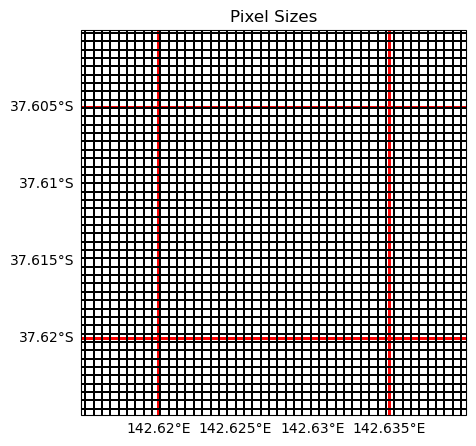

In [11]:
fig, ax = plt.subplots(figsize=(13,5), subplot_kw=dict(projection=ccrs.PlateCarree()))
prefire_oci_ds["rhos"].sel({"wavelength_3d":860}, method="nearest").plot(vmin=-1, vmax=0, cmap="Greys_r", transform=ccrs.PlateCarree(),linewidth=2, edgecolors="red", add_colorbar=False)
prefire_emit_ds["reflectance"].sel({"wavelengths":860}, method="nearest").plot(vmin=0, vmax=1, cmap="viridis", transform=ccrs.PlateCarree(), linewidth=0.05, edgecolors="k", add_colorbar=False, alpha=1)
ax.set_extent([142.615, 142.64, -37.625, -37.60])
ax.gridlines(draw_labels={"left": "y", "bottom": "x"}, alpha=0.0)
ax.set_title("Pixel Sizes")
plt.show()

The discrepancy in pixel size here can be fixed by regridding OCI data with EMIT's specification. Thanks to the processing steps we took in Section 2, we have access to the EMIT grid parameters in the form of its affine transform. We can feed that tranform into the `grid_data` function to coerce the PACE data into that shape. 

<div class="alert alert-warning" role="alert">

It is important to note that sharpening the data does not increase the information content of the data.

</div>

In other words, this approach will be using existing values to fill a larger quantity of pixels covering the same spatial extent, enabling us to stack granules and compare spectra, do band math, and more.

In [12]:
prefire_oci_finer = pace.grid_data(src=prefire_oci_ds, 
                                   dst_transform=prefire_emit_ds.rio.transform())
postfire_oci_finer = pace.grid_data(src=postfire_oci_ds, 
                                    dst_transform=postfire_emit_ds.rio.transform())

After the regridding is done, we can plot the pixel boundaries again to see if they align as we intend them to. 

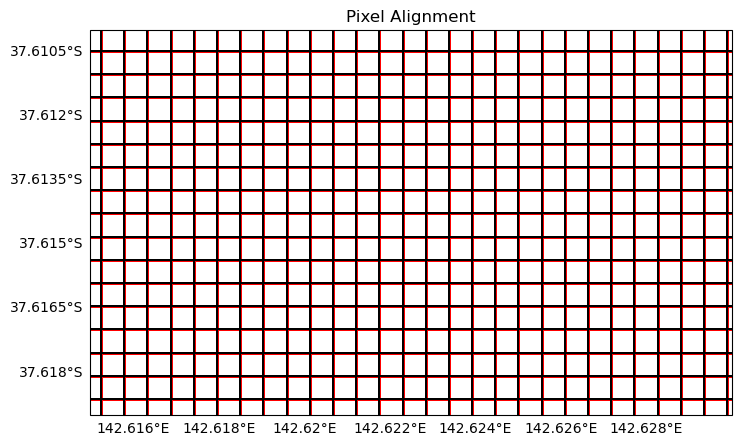

In [13]:
fig, ax = plt.subplots(figsize=(13,5), subplot_kw=dict(projection=ccrs.PlateCarree()))
prefire_oci_finer["rhos"].sel({"wavelength_3d":860}, 
                   method="nearest").plot(vmin=-1, vmax=0, cmap="Greys_r", 
                                          transform=ccrs.PlateCarree(), 
                                          linewidth=2, edgecolors="red", 
                                          add_colorbar=False)
prefire_emit_ds["reflectance"].sel({"wavelengths":860}, 
                             method="nearest").plot(vmin=0, vmax=1, 
                                                    transform=ccrs.PlateCarree(),  
                                                    linewidth=0.05, edgecolors="k", 
                                                    add_colorbar=False)

ax.set_extent([142.615, 142.63, -37.619, -37.61])
ax.gridlines(draw_labels={"left": "y", "bottom": "x"}, alpha=0.0)
ax.set_title("Pixel Alignment")
plt.show()

With the plot above, we can see that the pixels now align. Take a look at the shape of each dataset, as well - their x and y dimensions should match in size. 

## 4. Spectral Comparisons

With our granules now preprocessed and on the same grid, we can look at what some of the full spectral information looks like for our pre- and post-fire datasets. First, to simplify the plotting, we'll make sure our variable names are the same between each dataset by renaming the PACE variables. We'll also change EMIT's `nodata` values to `np.nan` instead of -9999, which would affect the color bar. 

In [14]:
# Band Masking for EMIT
prefire_emit_ds['reflectance'].data[:,:,prefire_emit_ds['good_wavelengths'].data==0] = np.nan
postfire_emit_ds['reflectance'].data[:,:,postfire_emit_ds['good_wavelengths'].data==0] = np.nan

# Rename PACE Vars
postfire_oci_finer = postfire_oci_finer.rename({
    "rhos": "reflectance",
    "wavelength_3d": "wavelengths",
})
prefire_oci_finer = prefire_oci_finer.rename({
    "rhos": "reflectance",
    "wavelength_3d": "wavelengths",
})

We'll then use `hvplot` to create a hoverplot displaying the spectral data. The cells below create true color images from the post-fire OCI and EMIT datasets, which you can then hover over to show what the spectra from each time point and sensor looks like. 

In [ ]:
def scale_for_rgb(d_in):
    d_in = np.where(np.isnan(d_in), -9999, d_in)
    d = np.where(d_in < -9990, np.nan, d_in)
    d_out = np.zeros_like(d)
    for i in np.arange(d.shape[-1]):
        mi, ma = np.nanpercentile(d[:, :, i], [.5, 99.5])
        di = skimage.exposure.rescale_intensity(d_in[:, :, i], in_range=(mi, ma))
        if ~np.all(np.isnan(di)):
            di = skimage.exposure.equalize_hist(di)
        d_out[:, :, i] = skimage.exposure.rescale_intensity(
            di, in_range=(di.min(), di.max())
        )
    return np.where(d_in > -9990, d_out, -9999)

rgb_ds_emit = postfire_emit_ds['reflectance'].sel(wavelengths=[650,560,470], method='nearest')
rgb_ds_oci = postfire_oci_finer['reflectance'].sel(wavelengths=[650,560,470], method='nearest')
rgb_ds_emit.data = scale_for_rgb(rgb_ds_emit.data)
rgb_ds_oci.data = scale_for_rgb(rgb_ds_oci.data)

In [16]:
rows, cols = len(rgb_ds_emit.latitude), len(rgb_ds_emit.longitude)
scene_center = rgb_ds_emit.latitude.values[int(rows/2)],rgb_ds_emit.longitude.values[int(cols/2)]

datasets = {
    "EMIT pre-fire":  prefire_emit_ds,
    "PACE pre-fire":  prefire_oci_finer,
    "EMIT post-fire": postfire_emit_ds,
    "PACE post-fire": postfire_oci_finer,
}
colors = {
    "EMIT pre-fire": "lightgreen", 
    "PACE pre-fire": "forestgreen",
    "EMIT post-fire":"darkorange", 
    "PACE post-fire":"firebrick",
}

# Set Start Position
x_start = scene_center[1]
y_start = scene_center[0]

# Plot RGB
rgb_map_emit = rgb_ds_emit.hvplot.rgb(
    x="longitude", y="latitude", bands="wavelengths",
    crs=ccrs.PlateCarree(),
    title="Stretched RGB EMIT Image",
    frame_width=240, frame_height=480
)

# Plot RGB
rgb_map_oci = rgb_ds_oci.hvplot.rgb(
    x="longitude", y="latitude", bands="wavelengths",
    crs=ccrs.PlateCarree(),
    title="Stretched RGB OCI Image",
    frame_width=240, frame_height=480
)

# Pointer stream
posxy = hv.streams.PointerXY(source=rgb_map_emit, x=x_start, y=y_start)

# Hover spectra function
def hover_spectra(x, y):
    plots = {}
    for label, ds in datasets.items():
        plots[label] = (
            ds["reflectance"]
            .sel(longitude=x, latitude=y, method="nearest")
            .hvplot.line(
                x="wavelengths", y="reflectance",
                label=label, color=colors[label], frame_width=480,
                frame_height=480
            )
        )
    return hv.NdOverlay(plots).opts(
        legend_position="right",
        show_legend=True
    )

hover_dmap = hv.DynamicMap(hover_spectra, streams=[posxy])

# Set Layout
hv.Layout(rgb_map_emit + hover_dmap + rgb_map_oci).cols(3).opts(
    hv.opts.Overlay(show_legend=True, fontscale=1.3, frame_height=480),
)

BokehModel(combine_events=True, render_bundle={'docs_json': {'095eba7a-432c-4db6-a4db-ee20694d336d': {'version…

### Mid-fire Time Series

So far, we have focused on the individual pre- and post-fire data from EMIT and OCI, but we also have OCI data from in between those days that we can explore. This area was subject to two forest fires, one of which (the Yarram Gap Road fire) started on December 16th. Let's take a slice of the area burned in that fire and look at the median spectrum over time, using each of the 12 OCI granules we gathered through the course of the fire. 

Looking at the plot below, we can see that as time progressed, the fire expanded over the full slice of the park we are looking at. The spectral signatures shifted, going from a classic representation of live, healthy vegetation to those which clearly show the transition to burnt material. The next two notebooks in this series will use the features of these time series spectra to characterize the fires which took place in our ROI.

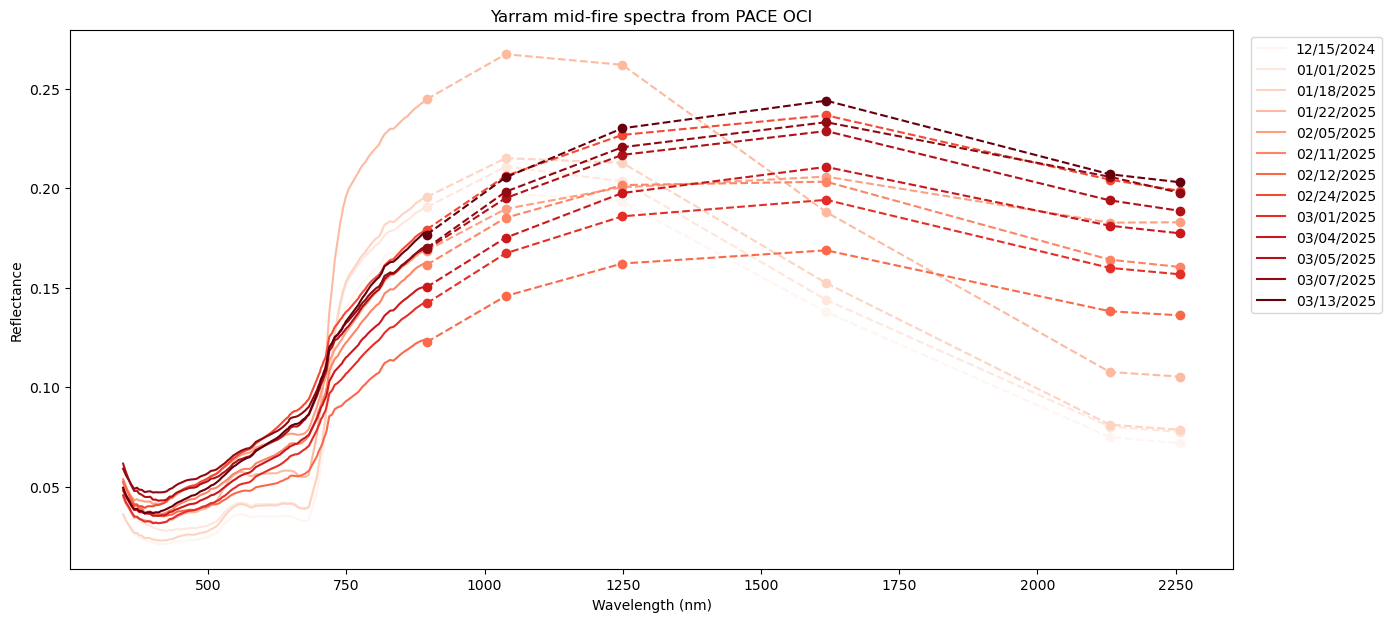

In [17]:
cmap = plt.get_cmap("Reds")
rgbs = cmap(np.linspace(0, 1, len(pace_ts_subsets)))

fig, ax = plt.subplots(figsize=(15,7))
for i in range(len(pace_ts_subsets)):
    ts=pace_ts_subsets[i].name[9:17]
    ds = xr.open_dataset(pace_ts_subsets[i])

    # Select section to compute the median on for the Yarram fire
    ds_yarram = ds["rhos"].sel({"longitude":slice(142.2, 142.3), 
                                "latitude":slice(-37.28, -37.4)}).median(dim=["latitude", "longitude"])
    
    ax.plot(ds["wavelength_3d"][:-6], ds_yarram[:-6], c=rgbs[i], label=f"{ts[4:6]}/{ts[6:]}/{ts[:4]}")
    ax.plot(ds["wavelength_3d"][-6:], ds_yarram[-6:], c=rgbs[i], ls='--', marker='o')
ax.set_title("Yarram mid-fire spectra from PACE OCI")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Reflectance")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
plt.show()
    

<div class="alert alert-info" role="alert">

You have completed the second notebook in the PACE+EMIT series. We suggest moving on to the third notebook, `03_Wildfires_with_PACE_EMIT`, which uses the data we processed here to investigate the wildfires which occurred in Grampians National Park, Victoria, Australia in 2024-2025.

</div>